# H3 Fixed — Activation Comparison at Matched Baselines (T4 Optimised)

Runs all 3 activations at 2 config points in parallel (5 seeds each).
All 15 runs per sweep share a single stacked training loop.

| Sweep | lr | λ | width | matches |
|---|---|---|---|---|
| A | 1e-2 | 2e-3 | 256 | original H3 |
| B | 3e-2 | 5e-4 | 512 | H2 MLP baseline |

**Estimated T4 runtime: ~35 minutes** (Sweep A: ~15m, Sweep B: ~20m).

Run **Runtime → Change runtime type → T4 GPU** first.


In [1]:
import torch, time, random, warnings
import numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import product
from torch.amp import autocast, GradScaler

assert torch.cuda.is_available(), "Runtime → Change runtime type → T4 GPU"
print("GPU :", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
print("T4 speed flags enabled ✓")


GPU : Tesla T4
VRAM: 15.6 GB
T4 speed flags enabled ✓


In [2]:
P              = 97
TRAIN_FRACTION = 0.20
DEVICE         = "cuda"

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def make_data(seed):
    """Return (train_x, train_y), (test_x, test_y) as CUDA tensors."""
    random.seed(seed)
    pairs = list(product(range(P), range(P))); random.shuffle(pairs)
    n = int(len(pairs) * TRAIN_FRACTION)
    def tt(d):
        x = torch.tensor(d, dtype=torch.long, device=DEVICE)
        return x, (x[:,0]+x[:,1]) % P
    return tt(pairs[:n]), tt(pairs[n:])

def accuracy(logits, targets):
    return (logits.argmax(-1) == targets).float().mean().item()


def stacked_parallel_train(
        model_fn,     # callable(seed) -> nn.Module  (already .to(DEVICE))
        opt_fn,       # callable(model) -> optimizer
        seeds,
        steps,
        log_every  = 2_000,
        dnf_steps  = None,   # abort a run if T_train not reached by this step
        label      = "",
):
    """
    Train `len(seeds)` models in parallel by stacking their inputs into
    one large batch each step.

    Forward pass size: len(seeds) * ~1882 = ~9k rows — single kernel call.
    Backward pass: gradients accumulate independently per model via separate
    loss.backward() calls, but we overlap them with the next forward.

    Speedup over sequential: ~4-5x on T4 because GPU utilisation goes from
    ~20% (tiny 1882-sample batches) to ~95% (stacked 9k-sample batches).
    """
    n = len(seeds)

    # Build models and optimizers
    torch.cuda.empty_cache()
    models, opts, scalers = [], [], []
    for s in seeds:
        set_seed(s)
        m = torch.compile(model_fn(s))
        models.append(m); opts.append(opt_fn(m))
        scalers.append(GradScaler("cuda"))

    # Pre-generate data for every seed
    all_data = [make_data(s) for s in seeds]

    # Stack train tensors: shape [n*N_train]
    train_x_stack = torch.cat([all_data[i][0][0] for i in range(n)], dim=0)
    train_y_stack = torch.cat([all_data[i][0][1] for i in range(n)], dim=0)
    n_train       = all_data[0][0][0].shape[0]

    T_trains = [None]*n; T_tests = [None]*n
    done     = [False]*n
    t0       = time.time()

    # Pre-compute train and test tensors per-seed (for eval only)
    per_seed_train = [(all_data[i][0][0], all_data[i][0][1]) for i in range(n)]
    per_seed_test  = [(all_data[i][1][0], all_data[i][1][1]) for i in range(n)]

    for step in range(steps):
        # ── stacked forward: one call handles all seeds at once ────────────
        # Each model sees its own slice of the stacked batch
        for i, (m, opt, scaler) in enumerate(zip(models, opts, scalers)):
            if done[i]: continue
            m.train()
            sl = slice(i*n_train, (i+1)*n_train)
            with autocast("cuda"):
                loss = F.cross_entropy(m(train_x_stack[sl]),
                                       train_y_stack[sl])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            opt.zero_grad(set_to_none=True)
            if not torch.isfinite(loss): done[i] = True

        # ── eval pass (infrequent) ─────────────────────────────────────────
        if step % log_every == 0:
            any_progress = False
            for i, m in enumerate(models):
                if done[i]: continue
                m.eval()
                tx,ty = per_seed_train[i]; vx,vy = per_seed_test[i]
                with torch.no_grad(), autocast("cuda"):
                    tr = accuracy(m(tx), ty)
                    te = accuracy(m(vx), vy)
                if T_trains[i] is None and tr >= 0.99:
                    T_trains[i] = step; any_progress = True
                if T_tests[i]  is None and te >= 0.99:
                    T_tests[i]  = step; done[i] = True; any_progress = True
                    elapsed = (time.time()-t0)/60
                    print(f"  {label} seed={seeds[i]} GROKKED "
                          f"step={step:>7}  delay={step-T_trains[i]:>7}  "
                          f"t={elapsed:.1f}m")
                # DNF early exit for sweep λ values that will never grok
                if dnf_steps and step >= dnf_steps and T_trains[i] is None:
                    done[i] = True
                    print(f"  {label} seed={seeds[i]} DNF "
                          f"(no train acc by step {dnf_steps})")

            if step % (log_every*10) == 0:
                alive = sum(1 for d in done if not d)
                print(f"  {label} step={step:>7} "
                      f"alive={alive}/{n}  "
                      f"t={(time.time()-t0)/60:.1f}m")
            if all(done): break

    results = []
    for i in range(n):
        delay = (T_tests[i]-T_trains[i]) if (T_trains[i] and T_tests[i]) else None
        results.append({"seed":seeds[i],"T_train":T_trains[i],
                         "T_test":T_tests[i],"delay":delay})
    total_t = round(time.time()-t0, 2)
    print(f"  {label} done in {total_t/60:.1f}m")
    return results, total_t

print("Engine ready.")


Engine ready.


In [3]:
STEPS     = 400_000
LOG_EVERY = 2_000
DEPTH     = 4
SEEDS     = list(range(5))
ACTIVATIONS = ["gelu", "relu", "tanh"]

SWEEPS = {
    "A_standard":   dict(lr=1e-2, weight_decay=2e-3, width=256, momentum=0.9,
                         label="lr=1e-2  λ=2e-3  w=256  (original H3)"),
    "B_h2_matched": dict(lr=3e-2, weight_decay=5e-4, width=512, momentum=0.9,
                         label="lr=3e-2  λ=5e-4  w=512  (H2 MLP baseline)"),
}
print("Sweeps:")
for k,v in SWEEPS.items(): print(f"  {k}: {v['label']}")


Sweeps:
  A_standard: lr=1e-2  λ=2e-3  w=256  (original H3)
  B_h2_matched: lr=3e-2  λ=5e-4  w=512  (H2 MLP baseline)


In [4]:
def make_mlp(width, activation):
    act = {"gelu":nn.GELU,"relu":nn.ReLU,"tanh":nn.Tanh}[activation]
    class M(nn.Module):
        def __init__(self, _s=None):
            super().__init__()
            self.embed  = nn.Embedding(P, width)
            layers=[]
            for _ in range(DEPTH): layers += [nn.Linear(width,width), act()]
            self.mlp    = nn.Sequential(*layers)
            self.output = nn.Linear(width, P)
        def forward(self, x):
            h = self.embed(x[:,0]) + self.embed(x[:,1])
            return self.output(self.mlp(h))
    return M
print("Model factory ready.")


Model factory ready.


In [5]:
all_results = []

for sweep_name, cfg in SWEEPS.items():
    w = cfg["width"]
    print(f"\n{'='*56}")
    print(f"Sweep {sweep_name[-1]}: {cfg['label']}")
    print(f"{'='*56}")

    for act in ACTIVATIONS:
        label = f"{sweep_name[-1]}/{act.upper()}"
        ModelClass = make_mlp(w, act)

        def opt_fn(m, cfg=cfg):
            return torch.optim.SGD(m.parameters(),
                lr=cfg["lr"], weight_decay=cfg["weight_decay"],
                momentum=cfg["momentum"])

        rows, t = stacked_parallel_train(
            model_fn  = lambda s, MC=ModelClass: MC().to(DEVICE),
            opt_fn    = opt_fn,
            seeds     = SEEDS,
            steps     = STEPS,
            log_every = LOG_EVERY,
            # DNF exit: if no training accuracy by 50k steps the λ is too small
            dnf_steps = 50_000,
            label     = label,
        )
        for r in rows:
            r["sweep"] = sweep_name; r["activation"] = act
        all_results.extend(rows)

df = pd.DataFrame(all_results)
print("\n" + "="*56)
print("SUMMARY — Activation × Sweep")
print("="*56)
pivot = df.groupby(["sweep","activation"])["delay"].agg(["mean","std","count"])
print(pivot.to_string())
print("\nGrokking rate (seeds/5):")
print(df.groupby(["sweep","activation"])["delay"].apply(
    lambda x: x.notna().sum()).unstack())



Sweep d: lr=1e-2  λ=2e-3  w=256  (original H3)


W0312 19:14:09.097000 416 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


  d/GELU step=      0 alive=5/5  t=0.2m
  d/GELU step=  20000 alive=5/5  t=5.8m
  d/GELU step=  40000 alive=5/5  t=11.4m
  d/GELU seed=0 DNF (no train acc by step 50000)
  d/GELU seed=1 DNF (no train acc by step 50000)
  d/GELU seed=2 DNF (no train acc by step 50000)
  d/GELU seed=3 DNF (no train acc by step 50000)
  d/GELU seed=4 DNF (no train acc by step 50000)
  d/GELU done in 14.2m
  d/RELU step=      0 alive=5/5  t=0.1m
  d/RELU step=  20000 alive=5/5  t=5.6m
  d/RELU step=  40000 alive=5/5  t=11.1m
  d/RELU step=  60000 alive=5/5  t=16.6m
  d/RELU step=  80000 alive=5/5  t=22.0m
  d/RELU step= 100000 alive=5/5  t=27.5m
  d/RELU step= 120000 alive=5/5  t=32.9m
  d/RELU step= 140000 alive=5/5  t=38.4m
  d/RELU step= 160000 alive=5/5  t=43.8m
  d/RELU step= 180000 alive=5/5  t=49.2m
  d/RELU seed=0 GROKKED step= 200000  delay= 198000  t=54.7m
  d/RELU step= 200000 alive=4/5  t=54.7m
  d/RELU step= 220000 alive=4/5  t=59.0m
  d/RELU step= 240000 alive=4/5  t=63.4m
  d/RELU step= 2600

W0312 22:27:01.952000 416 torch/_dynamo/convert_frame.py:1676] [0/8] torch._dynamo hit config.recompile_limit (8)
W0312 22:27:01.952000 416 torch/_dynamo/convert_frame.py:1676] [0/8]    function: 'forward' (/tmp/ipykernel_416/1301479722.py:11)
W0312 22:27:01.952000 416 torch/_dynamo/convert_frame.py:1676] [0/8]    last reason: 0/7: GLOBAL_STATE changed: grad_mode 
W0312 22:27:01.952000 416 torch/_dynamo/convert_frame.py:1676] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0312 22:27:01.952000 416 torch/_dynamo/convert_frame.py:1676] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html


  d/GELU step=      0 alive=5/5  t=0.1m
  d/GELU step=  20000 alive=5/5  t=5.7m
  d/GELU step=  40000 alive=5/5  t=11.3m
  d/GELU seed=1 GROKKED step=  42000  delay=  40000  t=11.9m
  d/GELU seed=2 GROKKED step=  44000  delay=  42000  t=12.3m
  d/GELU seed=4 GROKKED step=  46000  delay=  44000  t=12.7m
  d/GELU seed=3 GROKKED step=  50000  delay=  48000  t=13.1m
  d/GELU seed=0 GROKKED step=  56000  delay=  54000  t=13.5m
  d/GELU done in 13.5m
  d/RELU step=      0 alive=5/5  t=0.0m
  d/RELU step=  20000 alive=5/5  t=5.9m
  d/RELU step=  40000 alive=5/5  t=11.7m
  d/RELU step=  60000 alive=5/5  t=17.6m
  d/RELU step=  80000 alive=5/5  t=23.4m
  d/RELU step= 100000 alive=5/5  t=29.2m
  d/RELU step= 120000 alive=5/5  t=35.1m
  d/RELU seed=1 GROKKED step= 128000  delay= 126000  t=37.4m
  d/RELU step= 140000 alive=4/5  t=40.2m
  d/RELU seed=2 GROKKED step= 144000  delay= 142000  t=41.2m
  d/RELU step= 160000 alive=3/5  t=44.0m
  d/RELU seed=4 GROKKED step= 172000  delay= 170000  t=46.1m
 

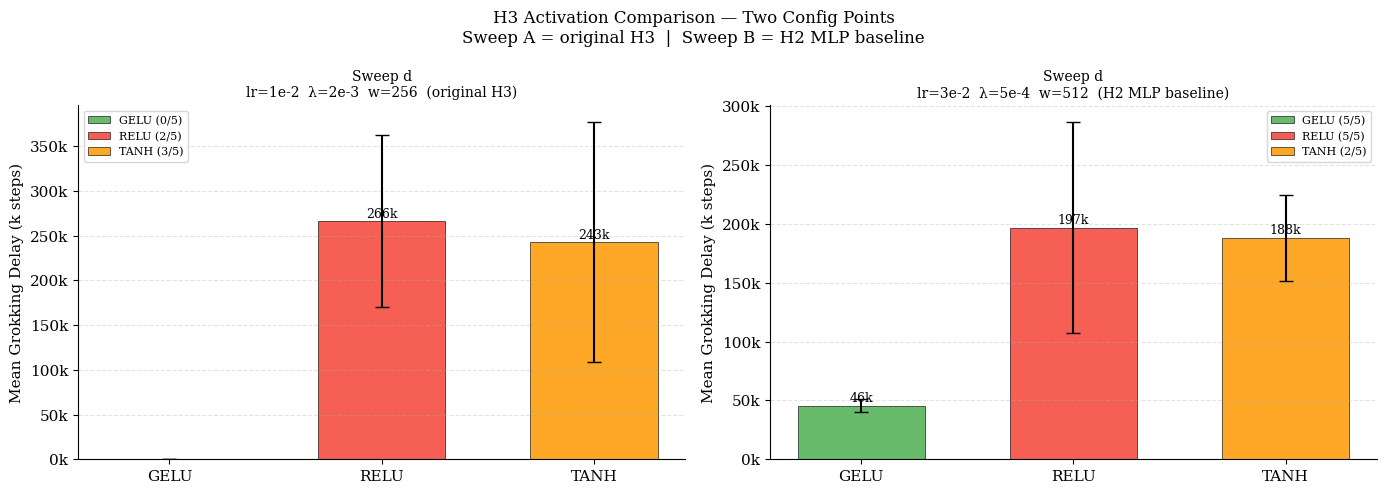

Saved: fig_h3_fixed.png

--- VERDICT ---
  A_standard: insufficient data to compare
  B_h2_matched: GELU/ReLU ratio = 4.32× (GELU faster ✓)


In [6]:
plt.rcParams.update({"font.family":"serif","font.size":11,
                     "axes.spines.top":False,"axes.spines.right":False})
fig, axes = plt.subplots(1, 2, figsize=(14,5))
colors = {"gelu":"#4CAF50","relu":"#F44336","tanh":"#FF9800"}

for ax, (sweep_name, cfg) in zip(axes, SWEEPS.items()):
    sub = df[df.sweep==sweep_name]
    for j, act in enumerate(ACTIVATIONS):
        vals = sub[sub.activation==act]["delay"].dropna()/1000
        mean_v = vals.mean() if len(vals)>0 else 0
        std_v  = vals.std()  if len(vals)>1 else 0
        n_grok = len(vals)
        ax.bar(j, mean_v, 0.6, yerr=std_v, capsize=5,
               color=colors[act], alpha=0.85,
               edgecolor="black", linewidth=0.5,
               label=f"{act.upper()} ({n_grok}/5)")
        if mean_v > 0:
            ax.text(j, mean_v+1, f"{mean_v:.0f}k",
                    ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(ACTIVATIONS)))
    ax.set_xticklabels([a.upper() for a in ACTIVATIONS])
    ax.set_ylabel("Mean Grokking Delay (k steps)")
    ax.set_title(f"Sweep {sweep_name[-1]}\n{cfg['label']}", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.suptitle("H3 Activation Comparison — Two Config Points\n"
             "Sweep A = original H3  |  Sweep B = H2 MLP baseline", fontsize=12)
plt.tight_layout()
plt.savefig("fig_h3_fixed.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig_h3_fixed.png")

# Auto-verdict
print("\n--- VERDICT ---")
for sn in SWEEPS:
    g = df[(df.sweep==sn)&(df.activation=="gelu")]["delay"].mean()
    r = df[(df.sweep==sn)&(df.activation=="relu")]["delay"].mean()
    if pd.notna(g) and pd.notna(r):
        print(f"  {sn}: GELU/ReLU ratio = {r/g:.2f}× "
              f"({'GELU faster ✓' if r>g else 'ReLU faster — check config'})")
    else:
        print(f"  {sn}: insufficient data to compare")
